In [112]:
import pandas as pd
import numpy as np

In [113]:
X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv")

df = X_train.merge(y_train, on="id")

In [114]:
df.shape


(59400, 41)

In [115]:
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [116]:
print(df.columns)

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='str')


In [117]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [118]:
df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='str')

In [119]:
# Check missing values
print(df.isnull().sum())

id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

In [120]:
numeric_cols = ['gps_height', 'longitude', 'latitude', 
                'num_private', 'population', 'construction_year']

df[numeric_cols] = df[numeric_cols].replace(0, np.nan)


# Numeric columns → mean imputation
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical columns → fill with "Unknown"
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
categorical_cols.remove('status_group')  # keep target untouched

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")
# Replace '0' strings or numbers with 'Unknown' for categorical columns
for col in categorical_cols:
    df[col] = df[col].replace(['0', 0], 'Unknown')

In [121]:
for col in categorical_cols:
    if (df[col] == '0').any() or (df[col] == 0).any():
        print(col, df[col].value_counts().loc[['0', 0]] if '0' in df[col].values or 0 in df[col].values else '')

In [122]:
# Check missing values
print(df.isnull().sum())

id                       0
amount_tsh               0
date_recorded            0
funder                   0
gps_height               0
installer                0
longitude                0
latitude                 0
wpt_name                 0
num_private              0
basin                    0
subvillage               0
region                   0
region_code              0
district_code            0
lga                      0
ward                     0
population               0
public_meeting           0
recorded_by              0
scheme_management        0
scheme_name              0
permit                   0
construction_year        0
extraction_type          0
extraction_type_group    0
extraction_type_class    0
management               0
management_group         0
payment                  0
payment_type             0
water_quality            0
quality_group            0
quantity                 0
quantity_group           0
source                   0
source_type              0
s

In [123]:
df.drop_duplicates(inplace=True)


In [124]:
# Convert date_recorded to datetime
df['date_recorded'] = pd.to_datetime(df['date_recorded'])
# Extract year, month, day
df['year_recorded'] = df['date_recorded'].dt.year



In [125]:
df['status_group'].value_counts()

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

<Axes: xlabel='status_group'>

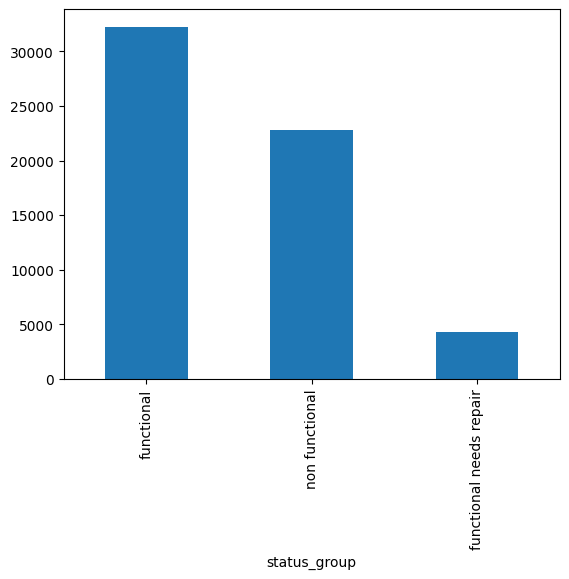

In [126]:
df['status_group'].value_counts().plot(kind='bar')

In [127]:
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(col, df[col].nunique())

funder 1895
installer 2144
wpt_name 37399
basin 9
subvillage 19288
region 21
lga 125
ward 2092
public_meeting 2
recorded_by 1
scheme_management 12
scheme_name 2696
permit 2
extraction_type 18
extraction_type_group 13
extraction_type_class 7
management 12
management_group 5
payment 7
payment_type 7
water_quality 8
quality_group 6
quantity 5
quantity_group 5
source 10
source_type 7
source_class 3
waterpoint_type 7
waterpoint_type_group 6
status_group 3


In [128]:
# Drop useless + extreme columns
df.drop(['recorded_by', 'wpt_name', 'subvillage', 'scheme_name', 'ward'], axis=1, inplace=True)

In [129]:
top_installers = df['installer'].value_counts().nlargest(10).index

df['installer_grouped'] = df['installer'].apply(
    lambda x: x if x in top_installers else 'Other'
)

In [130]:
top_funders = df['funder'].value_counts().nlargest(10).index

df['funder_grouped'] = df['funder'].apply(
    lambda x: x if x in top_funders else 'Other'
)

In [131]:
counts = df['lga'].value_counts()
df['lga_grouped'] = df['lga'].apply(lambda x: x if counts[x] > 150 else 'Other')

In [132]:
ct = pd.crosstab(df['lga_grouped'], df['status_group'])
ct_sorted = ct.sort_values(by='functional', ascending=False)
ct_sorted

status_group,functional,functional needs repair,non functional
lga_grouped,,,
Njombe,2007,94,402
Arusha Rural,875,48,329
Moshi Rural,733,119,399
Bagamoyo,730,2,265
Rungwe,676,161,269
...,...,...,...
Sikonge,49,0,121
Kiteto,45,28,120
Nanyumbu,42,0,116


In [133]:
df.describe()


,id,amount_tsh,date_recorded,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year,year_recorded
count,59400.000000,59400.000000,59400,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,2012-03-29 09:11:33.818181,1018.860839,35.149669,-5.706033e+00,37.204756,15.297003,5.629747,281.087167,1996.814686,2011.921667
min,0.000000,0.000000,2002-10-14 00:00:00,-90.000000,29.607122,-1.164944e+01,1.000000,1.000000,0.000000,1.000000,1960.000000,2002.000000
25%,18519.750000,0.000000,2011-04-01 00:00:00,903.000000,33.354079,-8.540621e+00,37.204756,5.000000,2.000000,100.000000,1996.000000,2011.000000
50%,37061.500000,0.000000,2012-10-10 00:00:00,1018.860839,35.149669,-5.021597e+00,37.204756,12.000000,3.000000,281.087167,1996.814686,2012.000000
75%,55656.500000,20.000000,2013-02-09 00:00:00,1319.250000,37.178387,-3.326156e+00,37.204756,17.000000,5.000000,281.087167,2004.000000,2013.000000
max,74247.000000,350000.000000,2013-12-03 00:00:00,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000,2013.000000
std,21453.128371,2997.574558,NaN,496.110517,2.567349,2.946019e+00,11.502588,17.587406,9.633649,451.765813,10.065781,0.958758


In [134]:
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)

id                       0.0
amount_tsh               0.0
date_recorded            0.0
funder                   0.0
gps_height               0.0
installer                0.0
longitude                0.0
latitude                 0.0
num_private              0.0
basin                    0.0
region                   0.0
region_code              0.0
district_code            0.0
lga                      0.0
population               0.0
public_meeting           0.0
scheme_management        0.0
permit                   0.0
construction_year        0.0
extraction_type          0.0
extraction_type_group    0.0
extraction_type_class    0.0
management               0.0
management_group         0.0
payment                  0.0
payment_type             0.0
water_quality            0.0
quality_group            0.0
quantity                 0.0
quantity_group           0.0
source                   0.0
source_type              0.0
source_class             0.0
waterpoint_type          0.0
waterpoint_typ

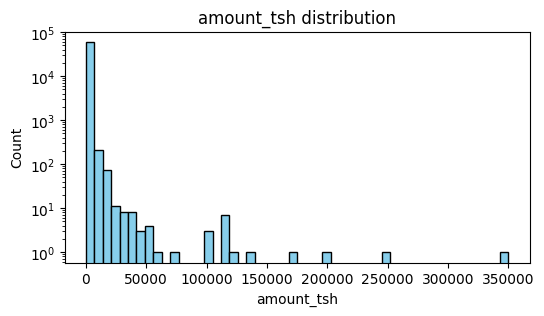

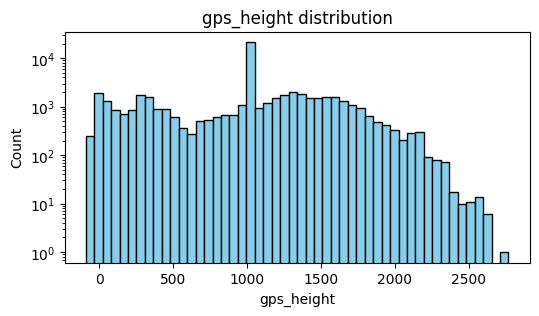

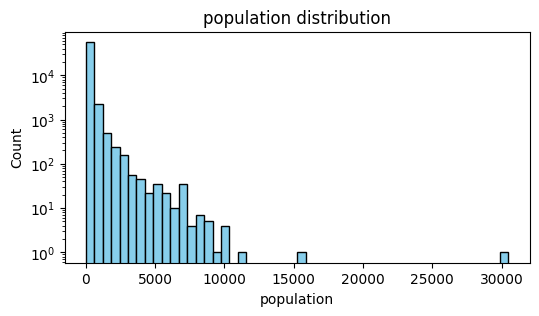

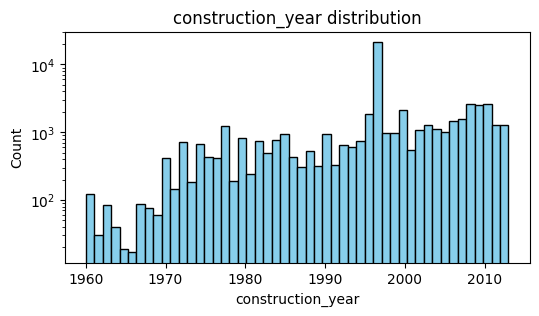

In [135]:
import matplotlib.pyplot as plt

numeric_cols = ['amount_tsh', 'gps_height', 'population', 'construction_year']

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=50, color='skyblue', edgecolor='black')
    plt.title(f'{col} distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.yscale('log')  # for skewed distributions
    plt.show()

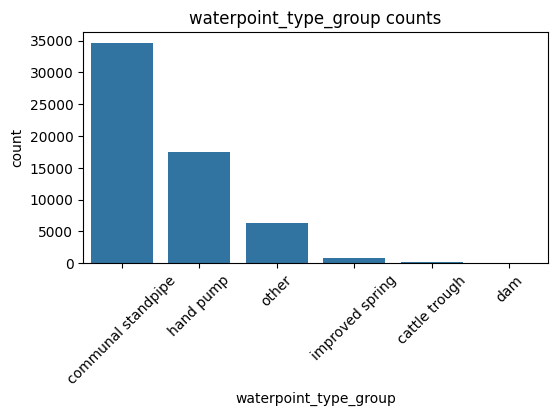

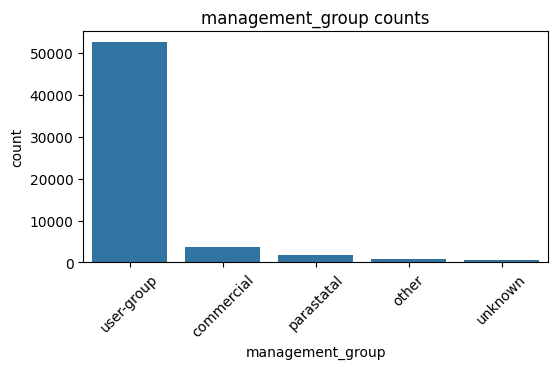

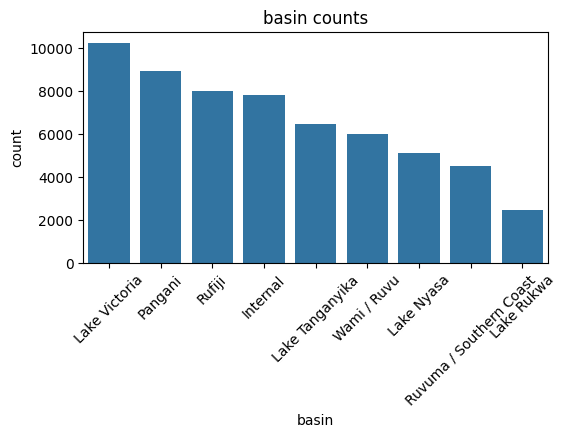

In [136]:
import seaborn as sns

categorical_cols = ['waterpoint_type_group', 'management_group', 'basin']

for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'{col} counts')
    plt.xticks(rotation=45)
    plt.show()

Do older pumps fail more often than newer ones?

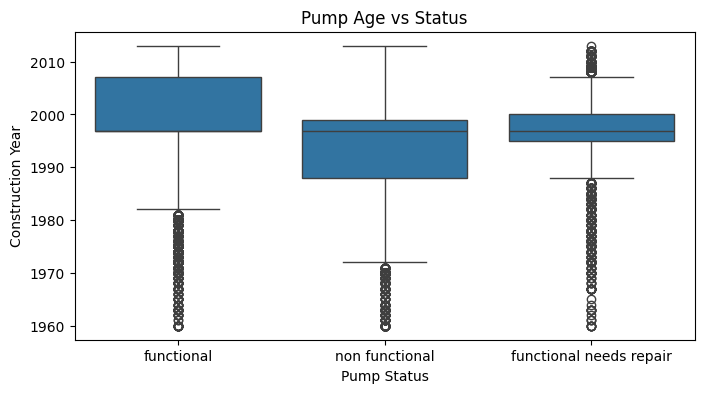

In [137]:
plt.figure(figsize=(8,4))
sns.boxplot(x='status_group', y='construction_year', data=df)
plt.title("Pump Age vs Status")
plt.xlabel("Pump Status")
plt.ylabel("Construction Year")
plt.show()

Are pumps serving larger populations more likely to be non-functional?

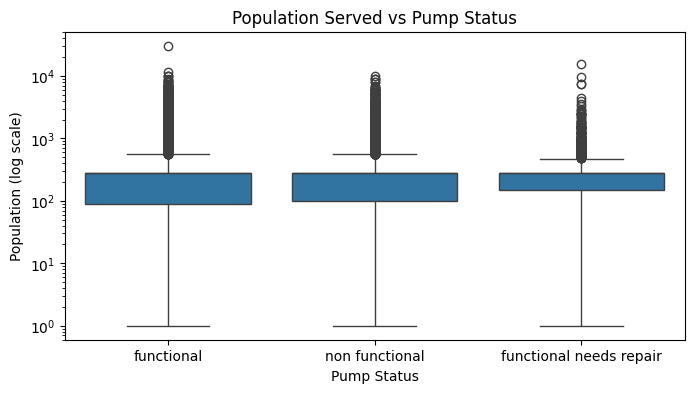

In [138]:
plt.figure(figsize=(8,4))
sns.boxplot(x='status_group', y='population', data=df)
plt.yscale('log')  # population is skewed
plt.title("Population Served vs Pump Status")
plt.xlabel("Pump Status")
plt.ylabel("Population (log scale)")
plt.show()

Are certain regions or basins more prone to pump failures?

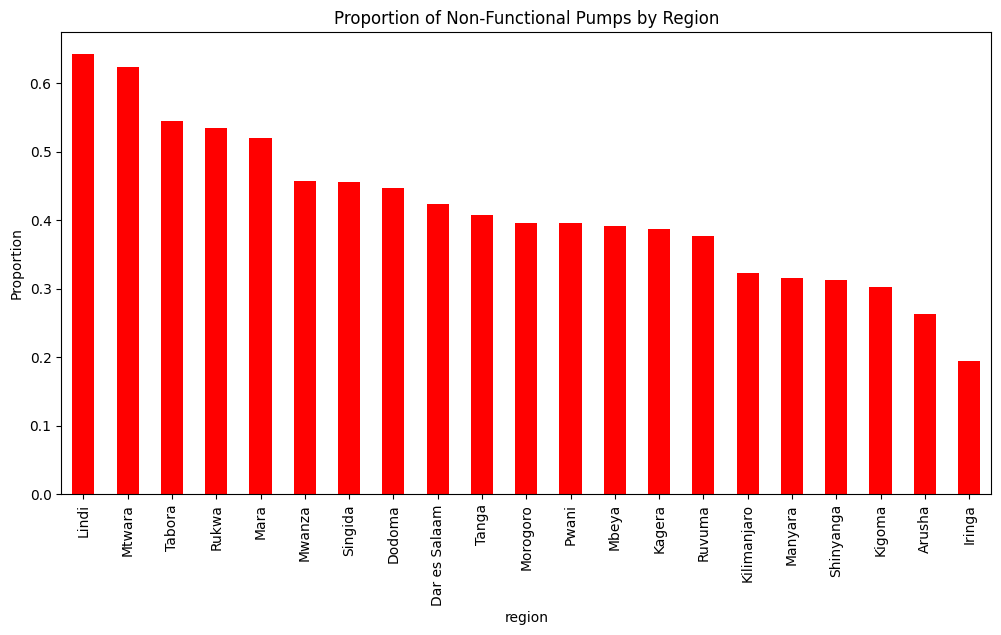

In [139]:
# Crosstab for region
region_status = pd.crosstab(df['region'], df['status_group'])
region_status_norm = region_status.div(region_status.sum(axis=1), axis=0)

non_func_rate = region_status['non functional'] / region_status.sum(axis=1)
non_func_rate.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='red')
plt.title("Proportion of Non-Functional Pumps by Region")
plt.ylabel("Proportion")
plt.show()

How does the installer relate to long-term functionality?

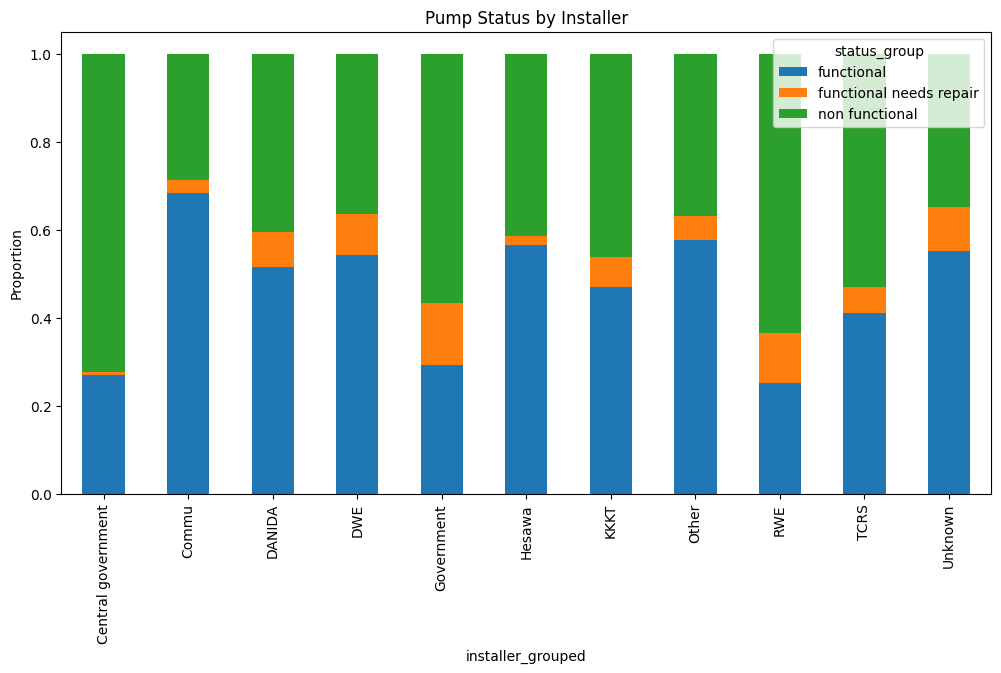

In [140]:
installer_status = pd.crosstab(df['installer_grouped'], df['status_group'])
installer_status_norm = installer_status.div(installer_status.sum(axis=1), axis=0)

installer_status_norm.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Pump Status by Installer")
plt.ylabel("Proportion")
plt.show()

Which pump types have the highest proportion of functional pumps?

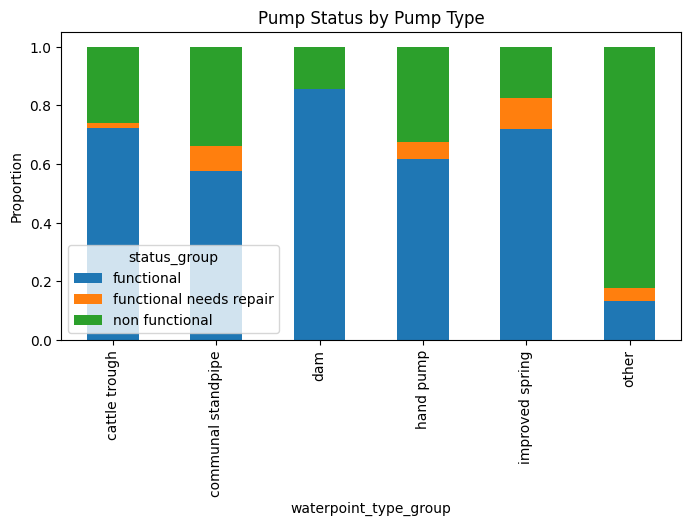

In [141]:
pump_type_status = pd.crosstab(df['waterpoint_type_group'], df['status_group'])
pump_type_status_norm = pump_type_status.div(pump_type_status.sum(axis=1), axis=0)

pump_type_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title("Pump Status by Pump Type")
plt.ylabel("Proportion")
plt.show()

Does water quality or quantity influence pump status?

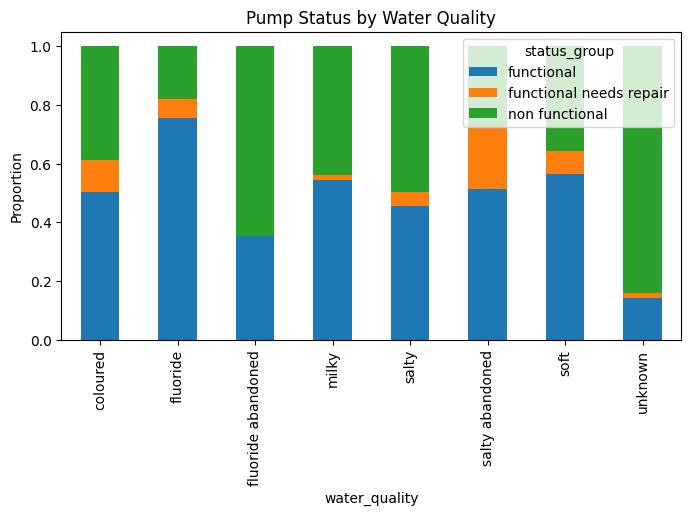

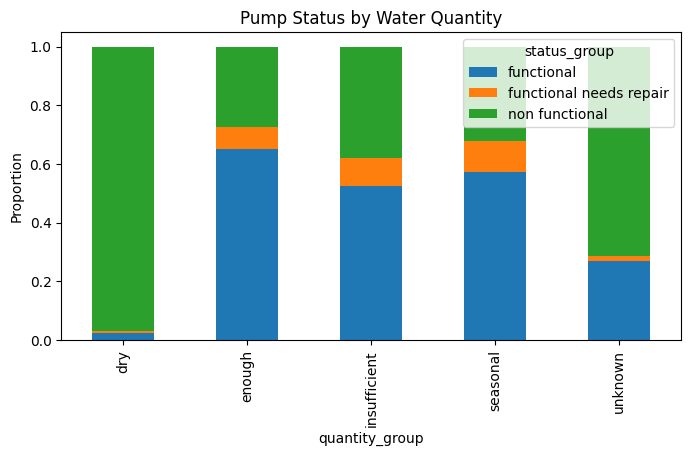

In [142]:
quality_status = pd.crosstab(df['water_quality'], df['status_group'])
quality_status_norm = quality_status.div(quality_status.sum(axis=1), axis=0)
quality_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title("Pump Status by Water Quality")
plt.ylabel("Proportion")
plt.show()

quantity_status = pd.crosstab(df['quantity_group'], df['status_group'])
quantity_status_norm = quantity_status.div(quantity_status.sum(axis=1), axis=0)
quantity_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title("Pump Status by Water Quantity")
plt.ylabel("Proportion")
plt.show()

How does the pump manager relate to long-term functionality?

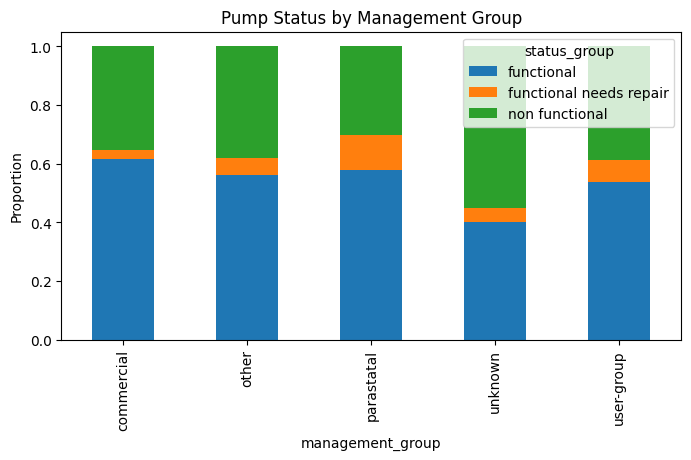

In [143]:
management_status = pd.crosstab(df['management_group'], df['status_group'])
management_status_norm = management_status.div(management_status.sum(axis=1), axis=0)

management_status_norm.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title("Pump Status by Management Group")
plt.ylabel("Proportion")
plt.show()